In [1]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
from matplotlib import pyplot as plt
import numpy as np
# from keras.preprocessing.image import ImageDataGenerator


2026-02-16 07:02:21.042846: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 07:02:21.058266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-16 07:02:21.074491: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-16 07:02:21.078905: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-16 07:02:21.092106: I tensorflow/core/platform/cpu_feature_guar

In [2]:
devices=tf.config.experimental.list_physical_devices()
devices

I0000 00:00:1771225343.770358   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225343.863663   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225343.863715   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
BATCH_SIZE=64
VAL_SIZE = 10000
RANDOM_SEED=67

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

LABELS = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
print("Train shape:", x_train.shape, y_train.shape)
print("Test  shape:", x_test.shape, y_test.shape)

Train shape: (50000, 32, 32, 3) (50000, 1)
Test  shape: (10000, 32, 32, 3) (10000, 1)


/tmp/ipykernel_85371/1377193937.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"{int(y[j])} - {LABELS[int(y[j])]}")


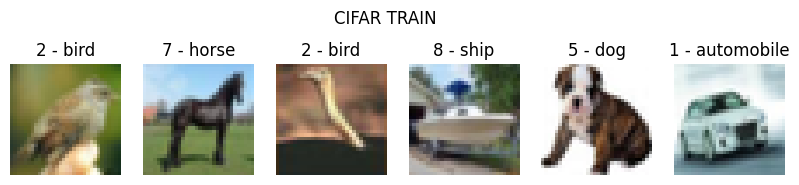

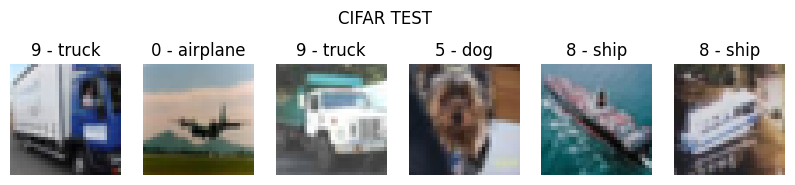

In [4]:
def visualize_data(x, y, title, n=6):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(10,4))
    for i, j in enumerate(idx):
        plt.subplot(2,6,i+1)
        plt.imshow(x[j], cmap="gray")
        plt.title(f"{int(y[j])} - {LABELS[int(y[j])]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

visualize_data(x_train, y_train, "CIFAR TRAIN")
visualize_data(x_test,  y_test,  "CIFAR TEST")


In [5]:
def class_distribution(y, name):
    y = y.reshape(-1)          # (N,1) -> (N,)
    y = y.astype(int)

    counts = np.bincount(y, minlength=10)
    total = len(y)

    print(f"\n{name}")
    for i in range(10):
        print(f"LABEL {i} - {LABELS[i]}: {counts[i]:5d}  ({counts[i]/total:.3f})")
class_distribution(y_train, "TRAIN")
class_distribution(y_test,  "TEST")


TRAIN
LABEL 0 - airplane:  5000  (0.100)
LABEL 1 - automobile:  5000  (0.100)
LABEL 2 - bird:  5000  (0.100)
LABEL 3 - cat:  5000  (0.100)
LABEL 4 - deer:  5000  (0.100)
LABEL 5 - dog:  5000  (0.100)
LABEL 6 - frog:  5000  (0.100)
LABEL 7 - horse:  5000  (0.100)
LABEL 8 - ship:  5000  (0.100)
LABEL 9 - truck:  5000  (0.100)

TEST
LABEL 0 - airplane:  1000  (0.100)
LABEL 1 - automobile:  1000  (0.100)
LABEL 2 - bird:  1000  (0.100)
LABEL 3 - cat:  1000  (0.100)
LABEL 4 - deer:  1000  (0.100)
LABEL 5 - dog:  1000  (0.100)
LABEL 6 - frog:  1000  (0.100)
LABEL 7 - horse:  1000  (0.100)
LABEL 8 - ship:  1000  (0.100)
LABEL 9 - truck:  1000  (0.100)


In [6]:
# Normalize

# x_train = x_train.astype("float32") / 255.0
# x_test  = x_test.astype("float32")  / 255.0

# x_train = x_train.reshape(len(x_train), -1)
# x_test  = x_test.reshape(len(x_test),  -1)

# Labels MUST be integers
y_train = y_train.astype("int32")
y_test  = y_test.astype("int32")


In [7]:

perm = tf.random.shuffle(tf.range(len(x_train)), seed=RANDOM_SEED)

x_train = tf.gather(x_train, perm)
y_train = tf.gather(y_train, perm)

x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train = x_train[:-VAL_SIZE]
y_train = y_train[:-VAL_SIZE]

print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)


I0000 00:00:1771225344.591924   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225344.591986   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225344.592010   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225344.737169   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1771225344.737208   85371 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-16

Train: (40000, 32, 32, 3) (40000, 1)
Val  : (10000, 32, 32, 3) (10000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [8]:
# y_train = tf.keras.utils.to_categorical(y_train, 10)
# y_val   = tf.keras.utils.to_categorical(y_val, 10)
# y_test  = tf.keras.utils.to_categorical(y_test, 10)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000, seed=RANDOM_SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE)

'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'''+ptx85+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

In [10]:
base_model = keras.applications.ResNet50( include_top=False, weights="imagenet", input_shape=(128, 128, 3), pooling="avg" )
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [11]:


inputs = keras.Input(shape=(32,32,3), name="input_image")

x = keras.layers.Resizing(128,128)(inputs)

# Correct preprocessing for EfficientNetV2
# x = keras.layers.Lambda(
#     keras.applications.efficientnet.preprocess_input
# )(x)

# Backbone (keep BN frozen in phase 1)
x = base_model(x, training=False)

# Custom classification head
x = keras.layers.Dense(512, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.BatchNormalization()(x)

outputs = keras.layers.Dense(10, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="CIFAR10_ConvNextTiny")
model.summary()


Model: "CIFAR10_ConvNextTiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,770 (94.50 MB)

 Trainable params: 24,719,114 (94.30 MB)

 Non-trainable params: 54,656 (213.50 KB)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [13]:
model.summary()

Model: "CIFAR10_ConvNextTiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,770 (94.50 MB)

 Trainable params: 24,719,114 (94.30 MB)

 Non-trainable params: 54,656 (213.50 KB)

In [ ]:

class MetricsStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        acc = logs.get("accuracy")
        val_acc = logs.get("val_accuracy")

        if acc is None or val_acc is None:
            return

        if acc > 0.90 and val_acc > 0.90 and acc >= val_acc:
            print(
                f"\n\nSufficient Metrics Reached! "
                f"acc={acc:.3f}, val_acc={val_acc:.3f}\n"
            )
            self.model.stop_training = True


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,
    patience = 2,
    min_lr   = 1e-7,
    verbose  = 1,
)


In [15]:
print("Fit model on training data")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[MetricsStopping(),reduce_lr]
)

Fit model on training data
Epoch 1/10


I0000 00:00:1771225381.610969   85693 service.cc:146] XLA service 0x7046b00044d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771225381.611009   85693 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-02-16 07:03:02.382009: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-16 07:03:04.680852: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2026-02-16 07:03:19.639339: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'loop_add_s

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7362 - loss: 0.8236

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 87ms/step - accuracy: 0.7363 - loss: 0.8231 - val_accuracy: 0.8474 - val_loss: 0.4593 - learning_rate: 3.0000e-04
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.9114 - loss: 0.2702 - val_accuracy: 0.8804 - val_loss: 0.3663 - learning_rate: 3.0000e-04
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.9365 - loss: 0.1900 - val_accuracy: 0.8602 - val_loss: 0.4809 - learning_rate: 3.0000e-04
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9535 - loss: 0.1380
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.9535 - loss: 0.1381 - val_accuracy: 0.8668 - val_loss: 0.4293 - learning_rate: 3.0000e-04
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9800 - loss: 0.0617 - val_accuracy: 0.9196 - val_loss: 0.2802 - learning_rate: 1.5000e-04
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.

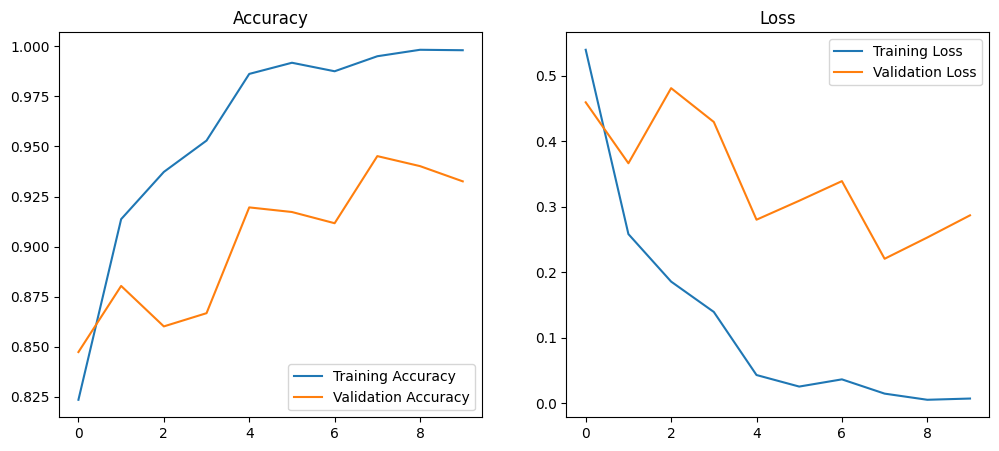

In [16]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9297 - loss: 0.3035
Test accuracy: 0.9301999807357788


In [18]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Confusion matrix, without normalization


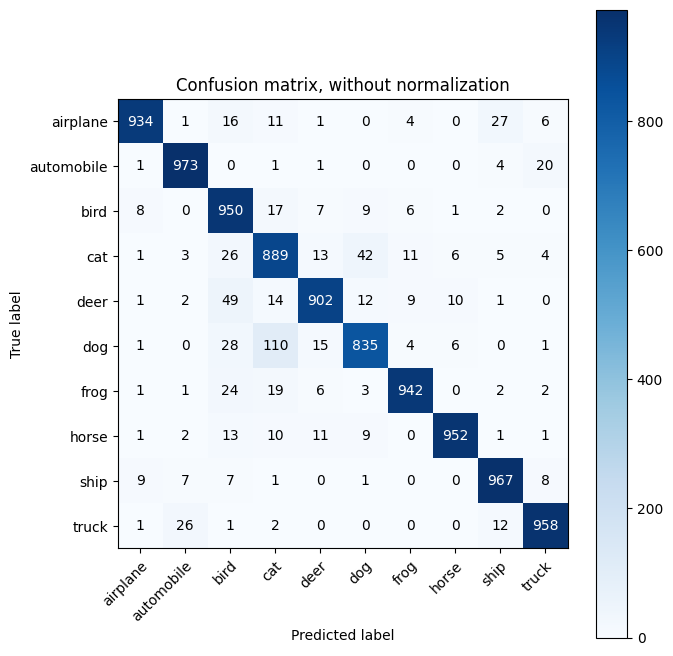

Normalized confusion matrix


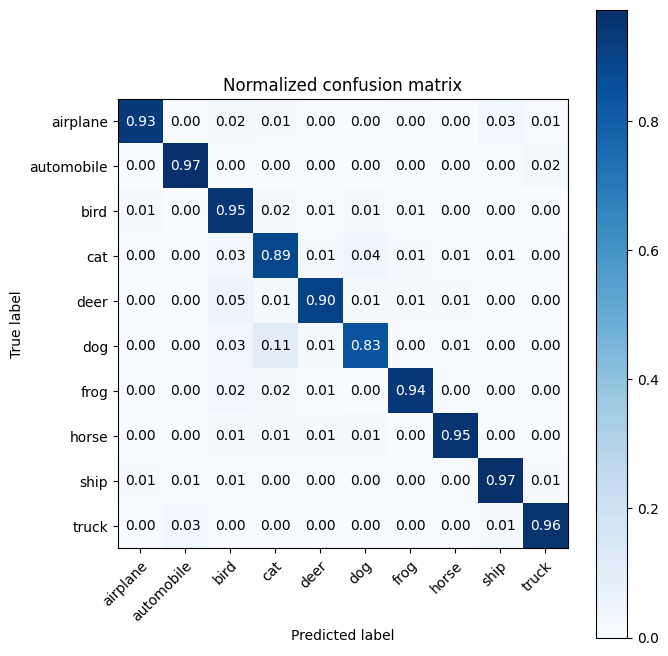

In [21]:
y_pred_probs = model.predict(test_ds)          
y_pred = np.argmax(y_pred_probs, axis=1)       
y_true = y_test.reshape(-1)                    

plot_confusion_matrix(y_true, y_pred, classes=LABELS)
plt.show()

plot_confusion_matrix(y_true, y_pred, classes=LABELS, normalize=True)
plt.show()

In [20]:
# model.save("mymodel.h5")